In [1]:
# Copyright 2026 Google LLC
# Use of this source code is governed by a BSD-style
# license that can be found in the LICENSE file.

%load_ext autoreload
%autoreload 2

In [5]:
import sys
import os

current_directory = os.getcwd()

sys.path.append(current_directory + "./../build/src/proto")
import nccl_telemetry_proto_pb2
from nccl_telemetry_proto_pb2 import DistType
from nccl_telemetry_proto_pb2 import ncclStatsConnectionType

ModuleNotFoundError: No module named 'nccl_telemetry_proto_pb2'

In [3]:
# Types of distributions/histograms we expect
dist_type_labels = {
    DistType.protoSendLatencySW: "Software Send Latency",
    DistType.protoRecvLatencySW: "Software Receive Latency",
    DistType.protoSendLatencyNetHW: "Network Hardware Send Latency",
    DistType.protoRecvLatencyNetHW: "Network Hardware Receive Latency",
    DistType.protoRecvReadylatency: "Receive Ready Latency",
    DistType.protoSendMessageSize: "Send Message Size",
    DistType.protoRecvMessageSize: "Receive Message Size",
}

# Number of type of histograms we expect
num_dist_types = max(dist_type_labels.keys())

time_unit = "Nanoseconds"

# Units
unit_labels = {
    DistType.protoSendLatencySW: time_unit,
    DistType.protoRecvLatencySW: time_unit,
    DistType.protoSendLatencyNetHW: time_unit,
    DistType.protoRecvLatencyNetHW: time_unit,
    DistType.protoRecvReadylatency: time_unit,
    DistType.protoSendMessageSize: "Bytes",
    DistType.protoRecvMessageSize: "Bytes",
}

In [4]:
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from datetime import datetime
from collections import defaultdict
from collections import namedtuple


# Prints all connection identifier data.
def print_conn_id(conn):
    print(
        "================== Connection Identification Information ========================="
    )
    conn_id = conn.connection_id
    print("Plug in name:", conn_id.nccl_plugin_name)
    print("GPU PCI ADDR:", conn_id.gpu_pci_addr)
    # print(conn_id.nccl_plugin_type)
    conn_info = conn_id.connection
    # print(conn_info.conn_type)
    extra_local, extra_remote = "", ""
    if conn_info.conn_type == ncclStatsConnectionType.EntityRDMAConnection:
        conn_type = "RDMA"
        stats_conn = conn_info.rdma_conn
        extra_local, extra_remote = f" (QPN: {stats_conn.local_qpn})", f"(QPN: {stats_conn.remote_qpn})"
    elif conn_info.conn_type == ncclStatsConnectionType.EntityTCPConnection:
        conn_type = "TCP"
        stats_conn = conn_info.tcp_conn
    else:
        conn_type = ""
    print("Connection Type:", conn_type)
    print("Local End-point:", stats_conn.local_endpoint, extra_local)
    print("Remote End-point:", stats_conn.remote_endpoint, extra_remote)
    print("Time Stamp:", datetime.fromtimestamp(conn.time_stamp.seconds))
    print("================== End Information =========================")


# The string concatenation of local and remote end-point is used as key to store data for a particular connection in a dictionary.
def get_connection_name(conn):
    conn_type = conn.connection_id.connection.conn_type
    if conn_type == ncclStatsConnectionType.EntityNVLConnection:
        # TODO
        return ""
    elif conn_type == ncclStatsConnectionType.EntityPCIConnection:
        # TODO
        return ""
    elif conn_type == ncclStatsConnectionType.EntityTCPConnection:
        connection = conn.connection_id.connection.tcp_conn
    elif conn_type == ncclStatsConnectionType.EntityRDMAConnection:
        connection = conn.connection_id.connection.rdma_conn
    else:
        # TODO
        return ""
    return connection.local_endpoint + "_" + connection.remote_endpoint


ConnectionData = namedtuple(
    "ConnectionData", ["time_stamp", "counts", "bounds", "min", "max", "avg"]
)


# For the given connection add data for current time-stamp.
def add_timestamp_data(connections, conn):
    name = get_connection_name(conn)
    if name not in connections:
        connections[name] = defaultdict(list)

    for hist in conn.histogram:
        max_bucket = hist.max_bucket
        base = hist.base
        scale = hist.scale_factor
        connections[name][hist.dist_type].append(
            ConnectionData(
                conn.time_stamp.seconds,
                [curr for curr in hist.bucket_counts],
                [(base**i)*scale for i in range(len(hist.bucket_counts))],
                hist.min,
                hist.max,
                hist.avg,
            )
        )

In [24]:
# Main dictionary to hold data aggregated per connection.
connections = defaultdict(list)

all_stats = nccl_telemetry_proto_pb2.AllStats()

# Directory where log files are stored.
directory = current_directory + "/../output/tmp"
txt_log_files = []

# Iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.startswith("exporter_") and filename.endswith(".log"):
        txt_log_files.append(os.path.join(directory, filename))

delimiter = b'==END=='

for path in txt_log_files:
    with open(path, "rb") as f:
        data = f.read()
        messages = data.split(delimiter)[:-1]
        for msg_data in messages:
            try:
                all_stats.ParseFromString(msg_data)
                if len(all_stats.conn_stats)==0:
                    print("empty!")
                for conn in all_stats.conn_stats:
                    print_conn_id(conn)
                    add_timestamp_data(connections, conn)
            except:
                pass



for name in connections.keys():
    for dist_type in dist_type_labels.keys():
        connections[name][dist_type].sort(key=lambda x: x.time_stamp, reverse=False)

1
================== Connection Identification Information =========================
Plug in name: StubPlugin
GPU PCI ADDR: 0000:8C:00.0
Local End-point: 
Remote End-point: 
Time Stamp: 2024-07-26 02:40:12
================== End Information =========================


In [ ]:
# For a given distribution of type dist_type make a heat-map or time-series chart showing change in distribution over time.
def make_time_series_plot(key, dist_type):
    list_of_timestamped_data = connections[key][dist_type]
    if list_of_timestamped_data:
        print("Connection Id:", key.split(":")[1])
        print("GPU PCI Addr:", conn.connection_id.gpu_pci_addr)
        times = [
            datetime.fromtimestamp(el.time_stamp) for el in list_of_timestamped_data
        ]

        data = np.array([hist.counts[::-1] for hist in list_of_timestamped_data])

        yticks = [int(el) for el in list_of_timestamped_data[0].bounds[::-1]]

        heatmap = sn.heatmap(data.T, yticklabels=yticks, cmap="viridis")

        yticklabels = heatmap.get_yticklabels()
        for i, label in enumerate(yticklabels):
            if i % 5 != 0:  # Display every second label (adjust condition as needed)
                label.set_visible(False)

        xlabels = [times[i] for i in range(0, len(times), 20)]
        plt.xticks(
            ticks=[i for i in range(0, len(times), 20)], labels=xlabels, rotation=90
        )

        plt.ylabel(unit_labels[dist_type])
        plt.title(dist_type_labels[dist_type])
        plt.tight_layout(pad=2.0)
        plt.savefig("figures/" + key + str(dist_type) + ".png")
        plt.show()


# Plot heat-maps for a single connection by providing the name which is just a string contanetation of local and remote endpoint.
# Plot heat-map for a single distribution by providing distribution id
dist_type = DistType.protoSendLatencySW
for key in connections.keys():
    make_time_series_plot(key, dist_type)

Connection Id: 80_128.0.0.1
GPU PCI Addr: GPU_PCI_ADDR


Connection Id: 80_128.0.0.1
GPU PCI Addr: GPU_PCI_ADDR


Connection Id: 80_128.0.0.1
GPU PCI Addr: GPU_PCI_ADDR


Connection Id: 80_128.0.0.1
GPU PCI Addr: GPU_PCI_ADDR


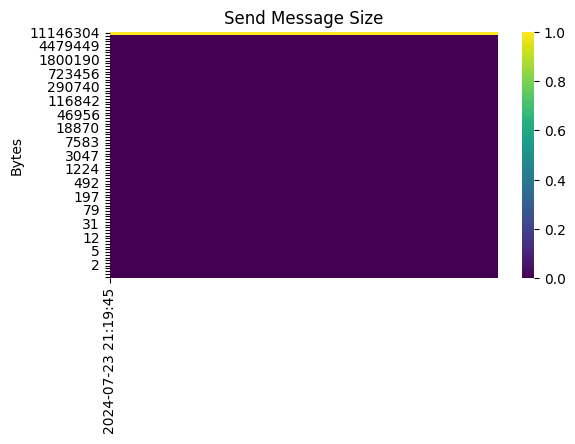

In [ ]:
# Plotting heat-maps for all connections and all their respective distributions.
for key, value in connections.items():
    for dist_type in dist_type_labels.keys():
        if connections[key][dist_type]:
            make_time_series_plot(key, dist_type)

[10.0] [datetime.datetime(2024, 7, 23, 21, 19, 45)]


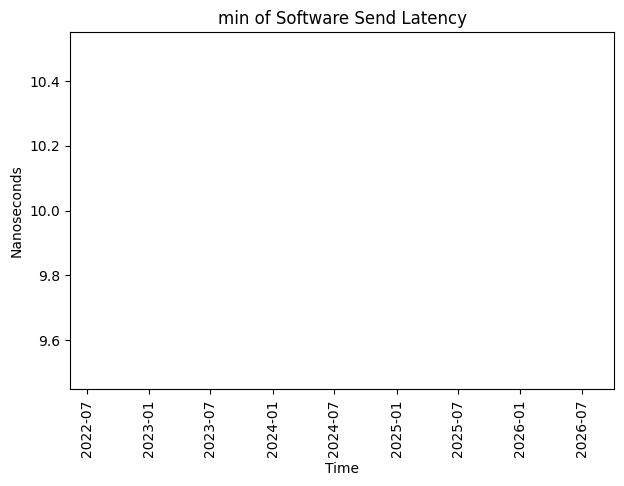

In [ ]:
def show_stats_for_all_conns(connections, dist_type, stat_type):
    for key in connections.keys():
        list_of_timestamped_data = connections[key][dist_type]
        if list_of_timestamped_data:
            times = [datetime.fromtimestamp(el[0]) for el in list_of_timestamped_data]
            data = [getattr(el, stat_type) for el in list_of_timestamped_data]
            print(data, times)
            plt.plot(times, data)

    plt.xticks(rotation=90)
    plt.tight_layout(pad=2.0)
    plt.xlabel("Time")
    plt.ylabel(unit_labels[dist_type])

    plt.title(stat_type + " of " + dist_type_labels[dist_type])
    plt.savefig("figures/"+key+str(dist_type)+stat_type+".png")

    plt.show()


dist_type = DistType.protoSendLatencySW
show_stats_for_all_conns(connections, dist_type, "min")
# show_stats_for_all_conns(connections, dist_type, "max")
# show_stats_for_all_conns(connections, dist_type, "avg")